# ML Parte 1 - Regressão
 Pedro Henrique Ferrari - 123676512



## Análise exploratória

Nesta etapa vamos analisar a distribuição da variável score e sua relação com algumas características dos alunos.

Primeiro, observamos a distribuição geral das notas. Em seguida, comparamos os valores de score de acordo com o número de reprovações (failures), o tempo de estudo (studytime) e a intenção de cursar ensino superior (higher).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("regressao/train.csv")

df.head()
df.columns



Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'score'],
      dtype='object')

In [2]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
score         0
dtype: int64

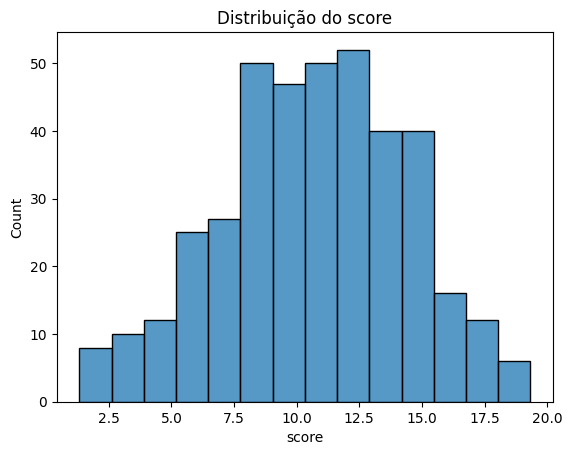

In [3]:
sns.histplot(df["score"])
plt.title("Distribuição do score")
plt.show()

## Correlação das variáveis numéricas e o Score


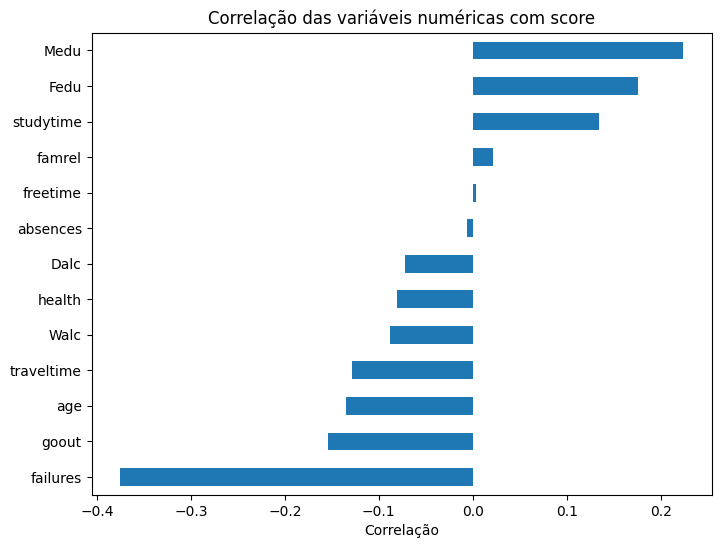

In [4]:
corr_score = (
    df.select_dtypes(include="number").corr()["score"].drop("score").sort_values()
)

corr_score.plot(kind="barh", figsize=(8, 6))
plt.title("Correlação das variáveis numéricas com score")
plt.xlabel("Correlação")
plt.show()

## Relação entre características dos alunos e o Score

Observamos o número de reprovações (failures), o tempo de estudo (studytime) e a intenção de cursar ensino superior (higher), comparando cada uma dessas características com o score.

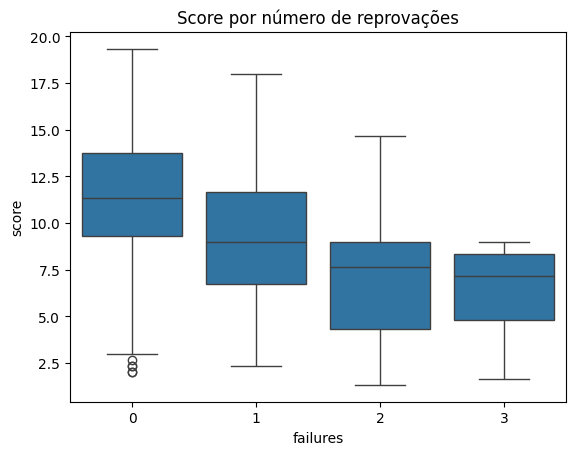

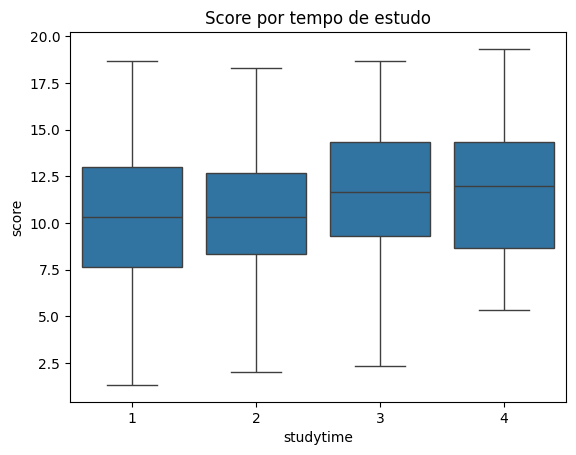

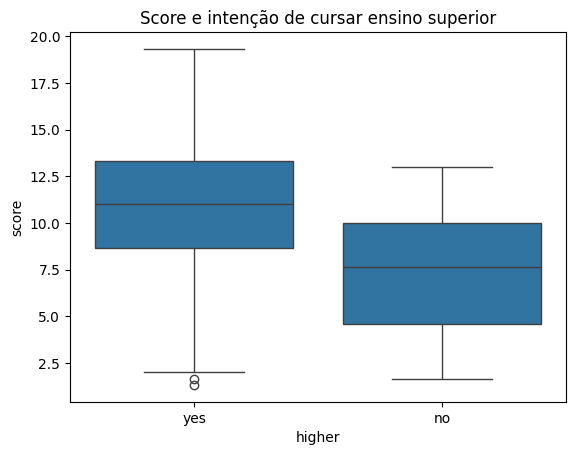

In [5]:
sns.boxplot(data=df, x="failures", y="score")
plt.title("Score por número de reprovações")
plt.show()


sns.boxplot(data=df, x="studytime", y="score")
plt.title("Score por tempo de estudo")
plt.show()

sns.boxplot(data=df, x="higher", y="score")
plt.title("Score e intenção de cursar ensino superior")
plt.show()

## Treinamento e comparação dos modelos

Nesta etapa, preparamos os dados, separamos treino e validação e aplicamos o pré-processamento. Em seguida, comparamos os modelos Regressão Linear, Random Forest e XGBoost utilizando validação cruzada com 5 divisões e o RMSE como métrica.

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, XGBClassifier
from sklearn.neighbors import KNeighborsClassifier



df = pd.read_csv("regressao/train.csv")

X_reg = df.drop(columns=["score"])
y_reg = df["score"]

colunas_categoricas = ["school", "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob", "reason", "guardian", "schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]

colunas_numericas = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]

# treino e validação
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Pré-processamento
preprocessador = ColumnTransformer([
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
    ("numericas", StandardScaler(), colunas_numericas)
    ])

# regressão linear
modelo_linear = Pipeline([
    ("preprocessamento", preprocessador),
    ("regressao", LinearRegression())
    ])
#random forest
modelo_random_forest = Pipeline([
    ("preprocessamento", preprocessador), 
    ("regressao", RandomForestRegressor(random_state = 42))
    ])
#XGboost
modelo_xgboost = Pipeline([
    ("preprocessamento", preprocessador),
    ("regressao", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

modelos = {
    "Linear Regression": modelo_linear,
    "Random Forest": modelo_random_forest,
    "XGBoost": modelo_xgboost
}

resultados = []

#Cross Validation para ver o modelo mais eficiente utilizando RMSE como métrica
for nome, modelo in modelos.items():
    rmse = cross_val_score(modelo, X_train_reg, y_train_reg, cv=5, scoring="neg_root_mean_squared_error")

    resultados.append({
        "Modelo": nome,
        "RMSE": -rmse.mean(),
        "Desvio padrão do RMSE": rmse.std()
    })

resultados_df = pd.DataFrame(resultados)
resultados_df.sort_values("RMSE")

,Modelo,RMSE,Desvio padrão do RMSE
1,Random Forest,3.213978,0.194630
2,XGBoost,3.427730,0.214399
0,Linear Regression,3.663275,0.128784


Vamos fazer tuning no Random Forest, que apresentou um RMSE menor em relação aos outros modelos. Faremos um GridSearchCV que vai testar as combinações de todos os parâmetros e ver qual é mais eficiente.

O tuning reduziu o RMSE médio da validação cruzada, encontrando uma configuração mais eficiente para o Random Forest.

In [7]:
parametros_rf = {
    "regressao__n_estimators": [100, 200, 300],
    "regressao__max_depth": [None, 5, 10, 20],
    "regressao__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    modelo_random_forest,
    parametros_rf,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_rf.fit(X_train_reg, y_train_reg)

print("Melhor RMSE:", -grid_rf.best_score_)
print("Melhores parâmetros:", grid_rf.best_params_)

Melhor RMSE: 3.18408709635115
Melhores parâmetros: {'regressao__max_depth': None, 'regressao__min_samples_leaf': 2, 'regressao__n_estimators': 100}



## TESTE

Carregamos o dataset de teste

In [8]:
test_reg = pd.read_csv("regressao/test.csv")
test_reg.shape
test_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      40 non-null     object
 1   sex         40 non-null     object
 2   age         40 non-null     int64 
 3   address     40 non-null     object
 4   famsize     40 non-null     object
 5   Pstatus     40 non-null     object
 6   Medu        40 non-null     int64 
 7   Fedu        40 non-null     int64 
 8   Mjob        40 non-null     object
 9   Fjob        40 non-null     object
 10  reason      40 non-null     object
 11  guardian    40 non-null     object
 12  traveltime  40 non-null     int64 
 13  studytime   40 non-null     int64 
 14  failures    40 non-null     int64 
 15  schoolsup   40 non-null     object
 16  famsup      40 non-null     object
 17  paid        40 non-null     object
 18  activities  40 non-null     object
 19  nursery     40 non-null     object
 20  higher      

In [9]:
modelo_eficiente = grid_rf.best_estimator_
modelo_eficiente.fit(X_train_reg, y_train_reg)

y_pred = modelo_eficiente.predict(X_val_reg)
#RMSE final para random forest
rmse_final = np.sqrt(mean_squared_error(y_val_reg, y_pred))
print("RMSE final:", rmse_final)

modelo_eficiente.fit(X_reg, y_reg)

preds = modelo_eficiente.predict(test_reg)

submission = pd.DataFrame({
    "id": range(len(preds)),
    "score": preds
})
display(submission)

print("Numero de nulos: ")
print(submission.isnull().sum())
print("Score minimo: ")
print(submission["score"].min())
print("Score maximo: ")
print(submission["score"].max())


submission.to_csv(
    "submission_regressao.csv",
    index=False
)

RMSE final: 3.282438358608771


,id,score
0,0,12.837971
1,1,11.289437
2,2,5.846606
3,3,11.531418
4,4,12.172785
5,5,10.392383
6,6,10.415073
7,7,10.575339
8,8,11.523407
9,9,10.445226


Numero de nulos: 
id       0
score    0
dtype: int64
Score minimo: 
4.245376904761903
Score maximo: 
12.837971071428568


# ML Parte 2 - Classificação

Pedro Henrique Ferrari 123676512

Para essa tarefa de classificação, ao invés de escolher o melhor modelo com parâmetros padrão e tuná-lo em seguida, iremos fazer um GridSearchCV em todos e escolher qual se sai melhor. 

In [10]:
df2 = pd.read_csv("classiicacao/train2.csv")

df2['diagnosis'].value_counts()
 


diagnosis
B    357
M    212
Name: count, dtype: int64

In [11]:
df2.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Analisamos a distribuição dos diagnósticos e comparamos algumas características entre casos benignos e malignos por meio de boxplots.

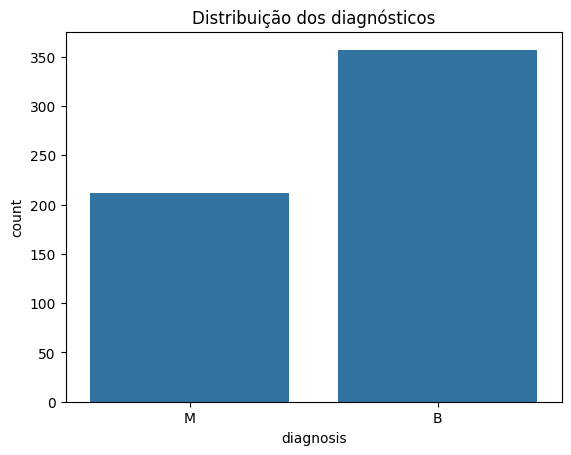

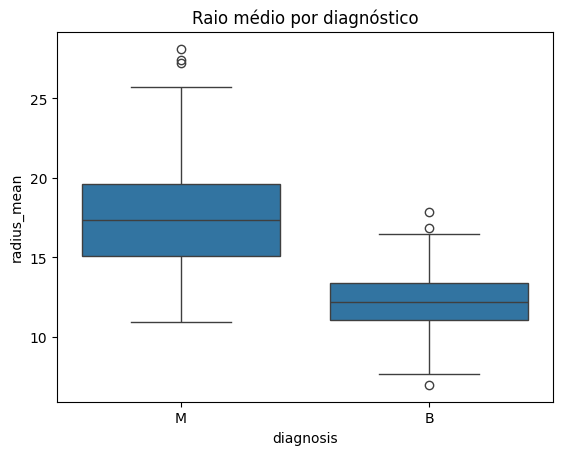

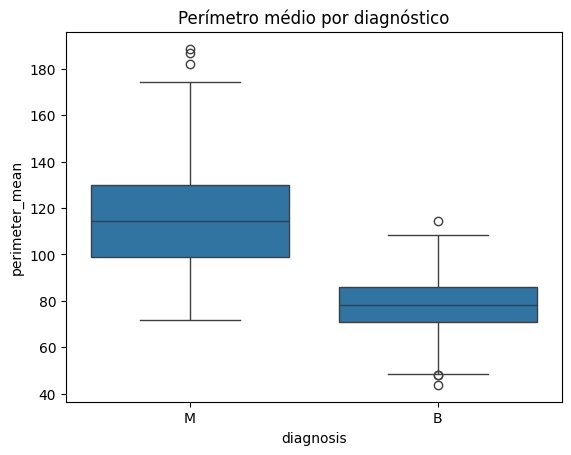

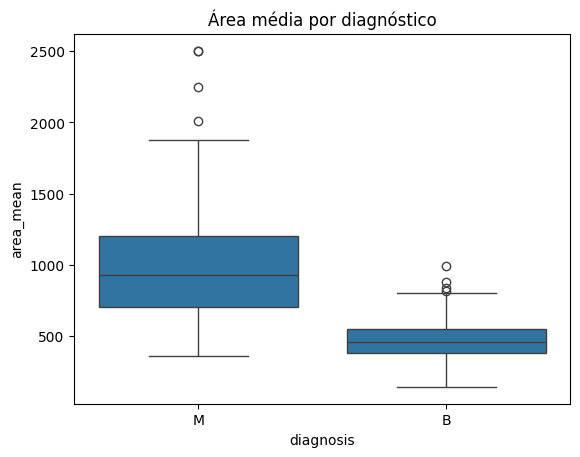

In [12]:
sns.countplot(data=df2, x="diagnosis")
plt.title("Distribuição dos diagnósticos")
plt.show()

sns.boxplot(data=df2, x="diagnosis", y="radius_mean")
plt.title("Raio médio por diagnóstico")
plt.show()

sns.boxplot(data=df2, x="diagnosis", y="perimeter_mean")
plt.title("Perímetro médio por diagnóstico")
plt.show()

sns.boxplot(data=df2, x="diagnosis", y="area_mean")
plt.title("Área média por diagnóstico")
plt.show()

Nessa primeira parte, transformamos os diagnósticos Maligno e Benigno em 1 e 0, respectivamente. Em seguida, padronizamos as variáveis numéricas com StandardScaler e comparamos Regressão Logística, KNN e XGBoost com seus parâmetros padrão. Utilizamos validação cruzada com 5 folds, analisando a acurácia média e seu desvio padrão.

In [13]:
X_clf = df2.drop(columns=["diagnosis"])
y_clf = df2["diagnosis"].map({
    "B": 0,
    "M": 1
})

# treino e validação
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

preprocessador_2 = ColumnTransformer([
    ("numericas", StandardScaler(), X_clf.columns)
]    
)

#Regressão Logistica
modelo_logistico = Pipeline([
    ("preprocessamento", preprocessador_2),
    ("regressao_log", LogisticRegression())
])

#KNN
modelo_knn = Pipeline([
    ("preprocessamento", preprocessador_2),
    ("knn", KNeighborsClassifier())
])

#XGB para classificação
modelo_xgboost_classifier = Pipeline([
    ("preprocessamento", preprocessador_2),
    ("xgbclassifier", XGBClassifier())
])

modelos_class = {
    "Logistic Regression": modelo_logistico,
    "KNN": modelo_knn,
    "XGBoost": modelo_xgboost_classifier
}

resultados_clf = []

for nome, modelo in modelos_class.items():
    acc = cross_val_score(modelo, X_train_clf, y_train_clf, cv=5, scoring="accuracy")

    resultados_clf.append({
        "Modelo": nome,
        "Accuracy": acc.mean(),
        "Desvio Padrao da Accuracy": acc.std()
    })

resultados_clf = pd.DataFrame(resultados_clf)
resultados_clf

,Modelo,Accuracy,Desvio Padrao da Accuracy
0,Logistic Regression,0.971429,0.011207
1,KNN,0.962637,0.022628
2,XGBoost,0.964835,0.030612


Na sequência, definimos conjuntos de hiperparâmetros para cada modelo e utilizamos GridSearchCV para buscar a melhor combinação com base na acurácia. 

Observamos que o XGBoost apresentou melhora após o tuning, enquanto Regressão Logística e KNN mantiveram resultados parecidos. Como a maior acurácia passou a ser do XGBoost, utilizaremos ele como modelo final. 

In [14]:
parametros_logistico = {
    "regressao_log__C": [0.01, 0.1, 1, 10, 100]
}

parametros_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"]
}

parametros_xgboost = {
    "xgbclassifier__n_estimators": [100, 200, 300],
    "xgbclassifier__max_depth": [2, 3, 5],
    "xgbclassifier__learning_rate": [0.01, 0.05, 0.1]
}

parametros_modelos = {
    "Logistic Regression": parametros_logistico,
    "KNN": parametros_knn,
    "XGBoost": parametros_xgboost
}

resultados_tuning = []
melhores_modelos = {}

for nome, modelo in modelos_class.items():

    grid = GridSearchCV(
        modelo,
        parametros_modelos[nome],
        cv=5,
        scoring="accuracy"
    )

    grid.fit(X_train_clf, y_train_clf)

    resultados_tuning.append({
        "Modelo": nome,
        "Melhor Accuracy": grid.best_score_,
        "Melhores Parametros": grid.best_params_
    })

    melhores_modelos[nome] = grid.best_estimator_

resultados_tuning = pd.DataFrame(resultados_tuning)

resultados_tuning

,Modelo,Melhor Accuracy,Melhores Parametros
0,Logistic Regression,0.971429,{'regressao_log__C': 0.1}
1,KNN,0.969231,"{'knn__n_neighbors': 7, 'knn__weights': 'unifo..."
2,XGBoost,0.973626,"{'xgbclassifier__learning_rate': 0.1, 'xgbclas..."


Avaliamos o melhor modelo no conjunto de validação utilizando acurácia e matriz de confusão.

O modelo apresentou acurácia de aproximadamente 97,36% no conjunto de validação. Na matriz de confusão, foram classificados corretamente 72 casos benignos e 39 casos malignos. O modelo apresentou 0 falsos positivos e 3 falsos negativos, demonstrando bom desempenho geral, embora os falsos negativos sejam especialmente relevantes por representarem casos malignos classificados incorretamente como benignos.

Accuracy final: 0.9736842105263158


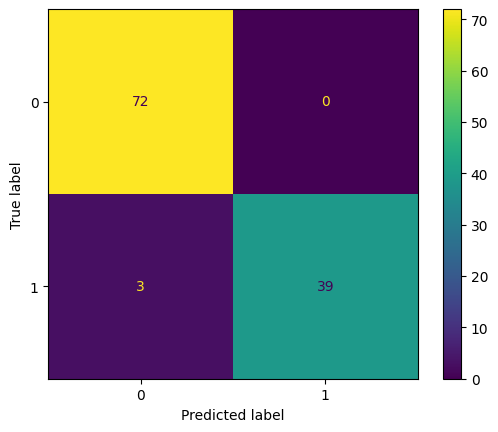

In [15]:
modelo_eficiente_clf = melhores_modelos["XGBoost"]

modelo_eficiente_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = modelo_eficiente_clf.predict(X_val_clf)

accuracy_final = accuracy_score(y_val_clf, y_pred_clf)

print("Accuracy final:", accuracy_final)

ConfusionMatrixDisplay.from_predictions(
    y_val_clf,
    y_pred_clf
)

plt.show()

Por fim, treinamos o modelo selecionado com todos os dados disponíveis e geramos as previsões para o conjunto de teste.

In [16]:
#Treino completo
modelo_eficiente_clf.fit(X_clf, y_clf)

#Teste
test_clf = pd.read_csv("classiicacao/test2.csv")
preds_clf = modelo_eficiente_clf.predict(test_clf)

print(preds_clf)

submission_clf = pd.DataFrame({
    "id": range(len(preds_clf)),
    "diagnosis": preds_clf
})

display(submission_clf)

print("Número de nulos:")
print(submission_clf.isnull().sum())

print("\nQuantidade por classe:")
print(submission_clf["diagnosis"].value_counts())

print("\nNúmero de linhas:")
print(len(submission_clf))

submission_clf.to_csv(
   "submission_classificacao.csv",
   index=False
)

[0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1
 0 1 0]


,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0
5,5,1
6,6,0
7,7,0
8,8,0
9,9,0


Número de nulos:
id           0
diagnosis    0
dtype: int64

Quantidade por classe:
diagnosis
0    28
1    12
Name: count, dtype: int64

Número de linhas:
40
